# Model Training
Step 1- Imports and data loaders

ImageFolder — automatically labels images based on their folder name (real/fake), since we organized them that way in Phase 8 — this is exactly why that folder structure mattered

Normalize(mean=..., std=...) — these specific numbers are the standard ImageNet normalization values; since EfficientNet was originally trained on ImageNet, matching this normalization helps the pretrained weights work correctly on our images

BATCH_SIZE = 16 — kept conservative given your 6GB VRAM; we can increase later if there's headroom, but starting safe avoids an out-of-memory crash mid-training

train_data.classes will print ['fake', 'real'] or ['real', 'fake'] (alphabetical) — important to note which index maps to which class

Config - loads project paths once. Works from any machine/clone location; only `config.py` needs to exist at the repo root.

In [1]:
# Cell 1 — Setup
from config import BASE_DIR, DATASETS_DIR, SAVED_MODELS_DIR
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_dir = str(DATASETS_DIR)
train_data = datasets.ImageFolder(f"{data_dir}/train", transform=transform)
val_data = datasets.ImageFolder(f"{data_dir}/validation", transform=transform)
test_data = datasets.ImageFolder(f"{data_dir}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_data.classes)
print("Train:", len(train_data), "Val:", len(val_data), "Test:", len(test_data))

Using device: cuda
Classes: ['fake', 'real']
Train: 9400 Val: 1500 Test: 1500


Step 2 - Load EfficientNet-B0 with pretrained weights, adapt for our 2-class problem

weights=EfficientNet_B0_Weights.DEFAULT — loads weights pretrained on ImageNet (millions of general images) instead of starting from random weights — this is transfer learning: the early layers already know how to detect edges, textures, shapes; we just need to retrain the final decision-making layer for our specific real/fake task

model.classifier[1].in_features — finds out how many features feed into the original final layer (so we match dimensions correctly)

nn.Linear(num_features, 2) — replaces that final layer with a fresh one that outputs exactly 2 values (fake-score, real-score) instead of 1000 ImageNet categories

model.to(device) — moves the entire model onto your GPU

In [2]:
# Cell 2 — Model, loss, optimizer
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


Step 3- Define loss function and optimizer

CrossEntropyLoss — the standard loss function for multi-class (including 2-class) classification problems; it measures how wrong the model's predicted probabilities are compared to the true label

Adam optimizer — an adaptive learning-rate optimizer, generally a safe, reliable default that converges well without much manual tuning

lr=0.0001 — a conservative learning rate appropriate for fine-tuning a pretrained model (much lower than you'd use training from scratch, since we don't want to drastically disturb the already-good pretrained weights)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Step 4- Training loop

model.train() vs model.eval() — switches the model between training mode (updates weights, applies dropout) and evaluation mode (no weight updates, dropout disabled) — critical distinction, a common beginner bug is forgetting this switch

optimizer.zero_grad() → loss.backward() → optimizer.step() — the core training triangle: clear old gradients, compute new ones via backpropagation, update weights

torch.no_grad() during validation — tells PyTorch not to track gradients here, since we're just checking performance, not training — saves memory and speeds things up
We save the model every time validation accuracy improves — this means even if training gets interrupted or overfits in later epochs, you keep the best version, not just whatever the last epoch produced

EPOCHS = 20
Epoch is a hyperparameter (external configuration setting) that defines one complete pass of the entire training dataset through learning algorithm.
Here its 20 means 20 passes complete pass of the entire training, allows model to adjust its parameters (weights and biases) steadily improving predictive accuracy.

In [3]:
# Cell 3 — Training / validation functions
def train_one_epoch():
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate():
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [4]:
# Cell 4 — Training loop with early stopping (saves real GPU time)
import time

EPOCHS = 20
PATIENCE = 4  # stop if val accuracy doesn't improve for 4 straight epochs

best_val_acc = 0.0
epochs_without_improvement = 0
training_start = time.time()

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), str(SAVED_MODELS_DIR / "efficientnet_best.pth"))
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"  No improvement for {PATIENCE} epochs — stopping early at epoch {epoch+1}.")
            break

total_time = time.time() - training_start
print(f"\nTraining complete in {total_time/60:.1f} minutes. Best validation accuracy: {best_val_acc:.4f}")

Epoch 1/20 | Train Loss: 0.3200, Train Acc: 0.8462 | Val Loss: 0.1086, Val Acc: 0.9507 | Time: 271.7s
  -> New best model saved (val_acc=0.9507)
Epoch 2/20 | Train Loss: 0.1480, Train Acc: 0.9407 | Val Loss: 0.0726, Val Acc: 0.9720 | Time: 153.6s
  -> New best model saved (val_acc=0.9720)
Epoch 3/20 | Train Loss: 0.0929, Train Acc: 0.9627 | Val Loss: 0.0623, Val Acc: 0.9687 | Time: 161.0s
Epoch 4/20 | Train Loss: 0.0684, Train Acc: 0.9752 | Val Loss: 0.0859, Val Acc: 0.9653 | Time: 163.5s
Epoch 5/20 | Train Loss: 0.0553, Train Acc: 0.9793 | Val Loss: 0.1189, Val Acc: 0.9493 | Time: 167.5s
Epoch 6/20 | Train Loss: 0.0443, Train Acc: 0.9824 | Val Loss: 0.0726, Val Acc: 0.9700 | Time: 159.7s
  No improvement for 4 epochs — stopping early at epoch 6.

Training complete in 18.0 minutes. Best validation accuracy: 0.9720


Installing libraries for next step

In [7]:
!pip install scikit-learn

Step 5 - Load best model and evaluate on test set

Loads the epoch-12 checkpoint (best validation performance), not the final epoch — matters because it's the actual best-performing version

Runs it on the test set — data the model never saw during training or checkpoint-selection, giving an honest final performance number

classification_report — prints precision, recall, F1-score, and support (count) for each class, plus overall accuracy

In [5]:
# Cell 5 — Evaluate on test set (reuses model/device already in memory)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(str(SAVED_MODELS_DIR / "efficientnet_best.pth"), map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=train_data.classes))

              precision    recall  f1-score   support

        fake       0.96      0.98      0.97       750
        real       0.98      0.95      0.97       750

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



Step 6 - Confusion matrix + ROC curve

Confusion matrix — shows exactly how many fake/real images were correctly vs incorrectly classified, as a 2×2 grid (diagonal = correct, off-diagonal = mistakes)

ROC curve — plots true positive rate vs false positive rate across different decision thresholds; AUC (Area Under Curve) close to 1.0 means the model separates the two classes very well regardless of exact threshold chosen

Saves the plot image directly into reports/ — useful for your project report/documentation later

plt.show() displays it inline in the notebook too

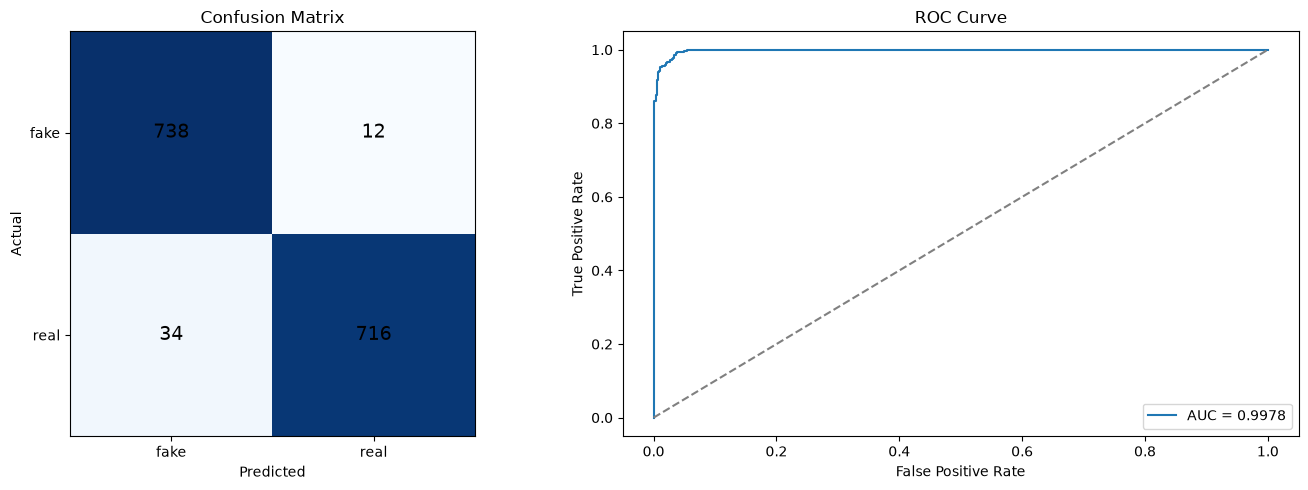

AUC Score: 0.9978


In [6]:
# Cell 6 — Confusion matrix + ROC curve
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(train_data.classes)
axes[0].set_yticklabels(train_data.classes)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(BASE_DIR / "reports" / "evaluation_plots.png"))
plt.show()

print(f"AUC Score: {auc_score:.4f}")